11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1, Loss: 0.0275
Epoch 2, Loss: 0.0158
Epoch 3, Loss: 0.0130
Epoch 4, Loss: 0.0116
Epoch 5, Loss: 0.0106
Epoch 6, Loss: 0.0094
Epoch 7, Loss: 0.0085
Epoch 8, Loss: 0.0078
Epoch 9, Loss: 0.0073
Epoch 10, Loss: 0.0069


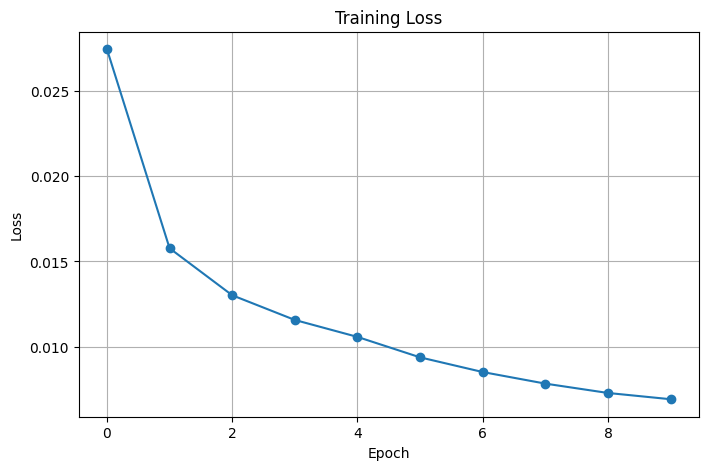

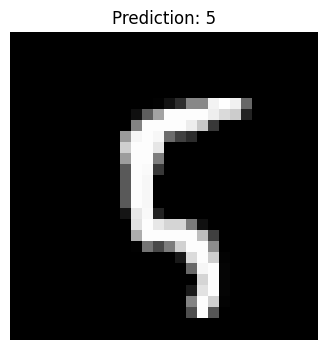

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from sklearn.preprocessing import OneHotEncoder

# Load MNIST dataset
(X_train, y_train), (_, _) = mnist.load_data()

# Preprocess input images
X_train = X_train.reshape(-1, 784) / 255.0

# One-hot encode labels
encoder = OneHotEncoder(sparse_output=False)
y_train = encoder.fit_transform(y_train.reshape(-1, 1))

# Initialize network
input_size = 784
hidden_size = 64
output_size = 10

W1 = np.random.randn(input_size, hidden_size) * 0.01
b1 = np.zeros((1, hidden_size))

W2 = np.random.randn(hidden_size, output_size) * 0.01
b2 = np.zeros((1, output_size))

# Activation function
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Derivative of sigmoid
def sigmoid_deriv(x):
    return x * (1 - x)

# Loss function
def loss_fn(y, y_hat):
    return -np.mean(y * np.log(y_hat + 1e-8))

# Training parameters
epochs = 10
lr = 0.1
losses = []

# Train the neural network
for epoch in range(epochs):
    total_loss = 0

    for i in range(X_train.shape[0]):
        x = X_train[i:i+1]
        y = y_train[i:i+1]

        # Forward propagation
        z1 = x @ W1 + b1
        a1 = sigmoid(z1)

        z2 = a1 @ W2 + b2
        a2 = sigmoid(z2)

        # Calculate loss
        loss = loss_fn(y, a2)
        total_loss += loss

        # Backpropagation
        dz2 = a2 - y
        dW2 = a1.T @ dz2
        db2 = dz2

        dz1 = (dz2 @ W2.T) * sigmoid_deriv(a1)
        dW1 = x.T @ dz1
        db1 = dz1

        # Update weights and biases
        W2 -= lr * dW2
        b2 -= lr * db2

        W1 -= lr * dW1
        b1 -= lr * db1

    # Store average loss
    epoch_loss = total_loss / X_train.shape[0]
    losses.append(epoch_loss)

    print(f"Epoch {epoch + 1}, Loss: {epoch_loss:.4f}")

# Plot training loss
plt.figure(figsize=(8, 5))
plt.plot(losses, marker='o')
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

# Prediction function
def predict(img):
    img = img.reshape(1, 784) / 255.0

    a1 = sigmoid(img @ W1 + b1)
    a2 = sigmoid(a1 @ W2 + b2)

    return np.argmax(a2)

# Predict a sample digit
idx = 100

plt.figure(figsize=(4, 4))
plt.imshow(X_train[idx].reshape(28, 28), cmap='gray')
plt.title(f"Prediction: {predict(X_train[idx])}")
plt.axis('off')
plt.show()